       Crop  Demand Index  Supply Index  Production Cost (USD/Ton)  \
0   Vanilla          3.68          6.25                    4271.54   
1   Sorghum          3.29          1.48                    3039.13   
2  Turmeric          6.38          1.75                    4592.59   
3   Lettuce          5.18          5.56                    2577.63   
4     Mango          5.17          4.30                    1367.70   

   Transportation Cost (USD/Ton)  Government Subsidy (USD/Ton)  \
0                          62.93                        364.22   
1                         885.86                        420.11   
2                         202.48                        187.36   
3                         217.51                         94.43   
4                         475.49                        358.31   

  Seasonal Effect International Trade Impact  Market Price (USD/Ton)  
0        Moderate                       High                 7067.21  
1             Low                       

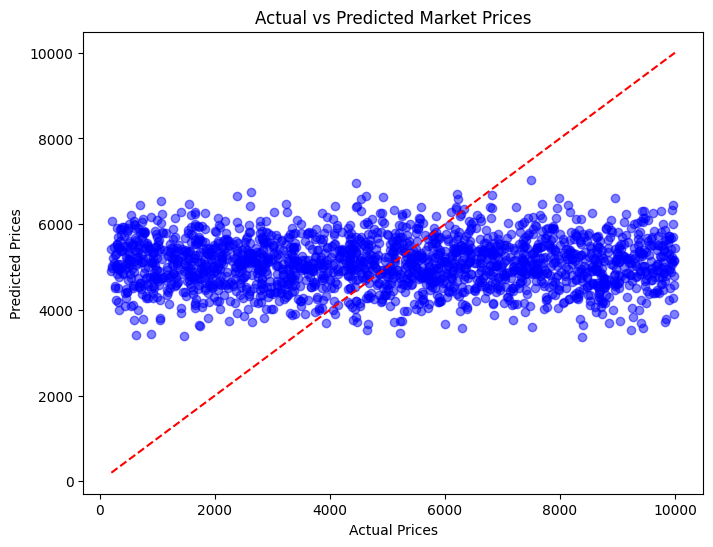

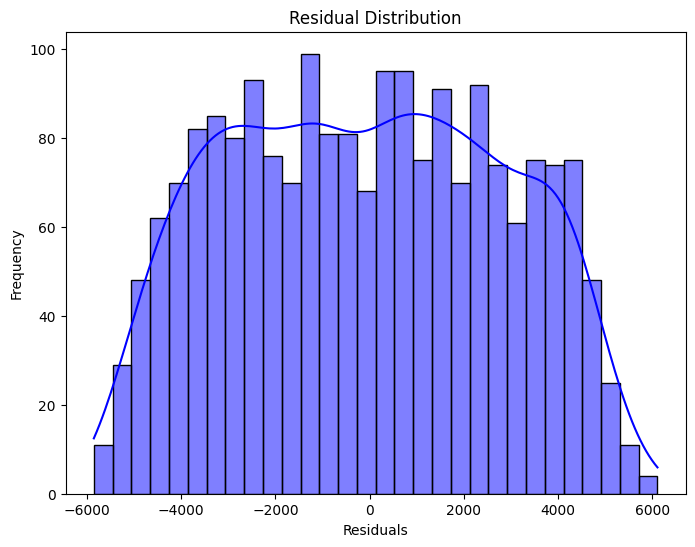

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
dataset_path = "/content/market_price_prediction_dataset.csv"  # Change this if needed
df = pd.read_csv(dataset_path)

# Display first few rows
print(df.head())

# Convert categorical columns into numerical using One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=["Seasonal Effect", "International Trade Impact"])

# Define feature set (X) and target variable (y)
X = df_encoded.drop(columns=["Crop", "Market Price (USD/Ton)"])  # Features
y = df["Market Price (USD/Ton)"]  # Target variable (Market price)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\n🔹 R² Score: {r2:.4f}")
print(f"🔹 Mean Absolute Error (MAE): {mae:.2f}")
print(f"🔹 Mean Squared Error (MSE): {mse:.2f}")
print(f"🔹 Root Mean Squared Error (RMSE): {rmse:.2f}")

# Scatter plot of Actual vs Predicted Prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Market Prices")
plt.show()

# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()
